In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Samples:", x_train.shape)
print("Testing Samples:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: (60000, 28, 28)
Testing Samples: (10000, 28, 28)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0


x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(x_train,
                    y_train,
                    epochs=5,
                    batch_size=128,
                    validation_split=0.2)


loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 126ms/step - accuracy: 0.7925 - loss: 0.5789 - val_accuracy: 0.8570 - val_loss: 0.4088
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.8680 - loss: 0.3688 - val_accuracy: 0.8676 - val_loss: 0.3601
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 120ms/step - accuracy: 0.8835 - loss: 0.3234 - val_accuracy: 0.8867 - val_loss: 0.3147
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 122ms/step - accuracy: 0.8936 - loss: 0.2923 - val_accuracy: 0.8935 - val_loss: 0.2988
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.9010 - loss: 0.2719 - val_accuracy: 0.8973 - val_loss: 0.2838
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8929 - loss: 0.2975
Test Loss: 0.29747629165649414
Test Accuracy: 0.8928999900817871


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Classes:
[9 2 1 1 6]


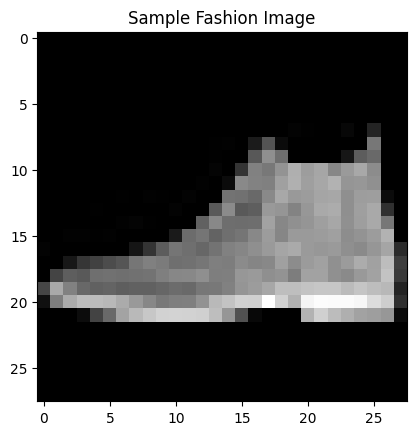

In [8]:

prediction = model.predict(x_test[:5])

print("Predicted Classes:")
print(np.argmax(prediction, axis=1))

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Sample Fashion Image")
plt.show()


